In [1]:
import time
import datetime as dt
import numpy as np
import pandas as pd
from rivapy.optimization.models.batterystorage import BatteryStorage
from rivapy.marketdata import EnergyPriceForwardCurve
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

C:\Users\Anwender\Documents\Python Scripts\RivaPy\RiVaPy\rivapy\__init__.py:11: UserWarning: The pyvacon module is not available. You may not use all functionality without this module. Consider installing pyvacon.
  warnings.warn('The pyvacon module is not available. You may not use all functionality without this module. Consider installing pyvacon.')


USE NUMBA: True


In [3]:
eff_in = 0.97
eff_out = 0.97
np.random.seed(25)
states = np.arange(0, 100.5, step=0.5, dtype=np.float32)
actions = np.arange(-25, 26)

timesteps = 96

prices = np.random.uniform(low=1, high=10, size=timesteps).astype(np.float32)
max_charges = np.array([0.0, 50.0, 100.0], dtype=np.float32)
max_capacity = 100.0

dates = [dt.datetime(2024, 1, 1) + dt.timedelta(days=i) for i in range(timesteps)]
pfc = EnergyPriceForwardCurve.from_existing_pfc(id="1", pfc=pd.DataFrame(data=prices, index=dates), refdate=dt.datetime.today())


batterystorage = BatteryStorage(
    eff_in=eff_in, eff_out=eff_out, max_capacity=max_capacity, pfc=pfc, max_charges=max_charges, states=states, actions=actions, precompile=True
)

In [4]:
start = time.time()
batterystorage.optimize()
end = time.time()
print(end - start)


0.29133105278015137


In [5]:
batterystorage_output = batterystorage.create_output()
batterystorage_output

1627.1349537670612


,DateTime,Price,SOC,ChargeCycle,Charging,Value
0,2024-01-01,8.831118,100.000000,0.0,-24.000000,205.588425
1,2024-01-02,6.240492,76.000000,0.0,0.000000,-0.000000
2,2024-01-03,3.509551,76.000000,0.0,0.000000,-0.000000
3,2024-01-04,2.673201,76.000000,0.0,0.000000,-0.000000
4,2024-01-05,4.699901,76.000000,0.0,0.000000,-0.000000
...,...,...,...,...,...,...
91,2024-04-01,8.115459,0.087296,100.0,0.000000,-0.000000
92,2024-04-02,1.303145,0.087296,100.0,0.000000,-0.000000
93,2024-04-03,8.163741,0.087296,100.0,-0.087296,0.691286
94,2024-04-04,7.204936,0.000000,100.0,0.000000,-0.000000


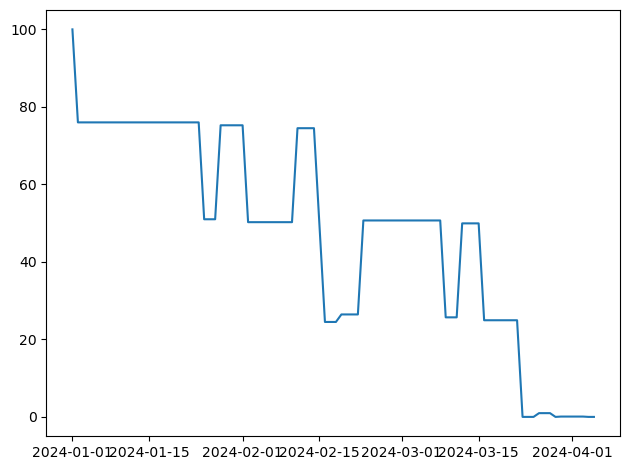

In [6]:
plt.plot(batterystorage_output['DateTime'], batterystorage_output['SOC'])
plt.tight_layout()

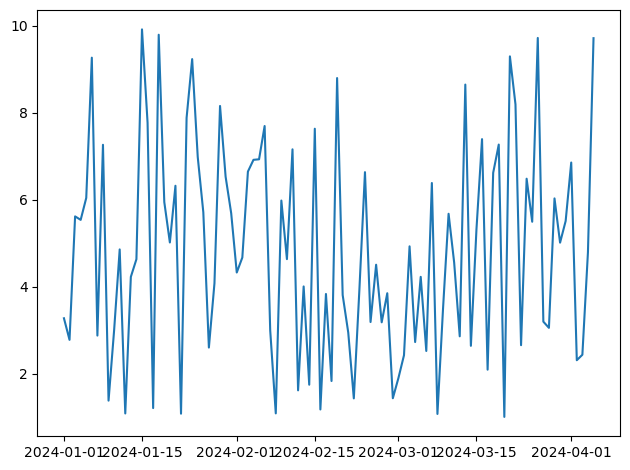

In [6]:
plt.plot(batterystorage_output['DateTime'], batterystorage_output['Price'])
plt.tight_layout()

In [18]:
test = np.array([[1,2,3], [4, 5, 6], [7,8,9]])

In [23]:
test[[0,1], :]

array([[1, 2, 3],
       [4, 5, 6]])